<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/Figure1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving snr_calculator_Silas.py to snr_calculator_Silas.py


{'snr_calculator_Silas.py': b'import numpy as np\r\n# Ps is the total launch power [W], lamb is the wavelength [nm], alpha is fiber attenuation [dB/km], NF is the noise figure of the amplifiers [dB], \r\n# N is the number of repeaters, gamma is the kerr nonlinearity [1/(W*km)], Ltot is the total cable length, B is the bandwidth [Hz], D is the dispersion [s/(km*nm)]\r\n# Rs is the baudrate [Hz], gamma_XT is the inter-core crosstalk [dB], l_FIFO is the loss of FIFOs [dB], delta_f is the channel spacing [dB]\r\n\r\n\r\n#gamma_XT is the cross-talk coefficient, below is based on "The Generalized Droop Model for Optical Long-Haul Transmission Systems" - Bononi, A. et al\r\ndef SNR_GD(Ps,lamb,alpha,NF,N,gamma,Ltot,B,D,Rs,gamma_XT,l_FIFO,delta_f):\r\n    \r\n    \r\n    h = 6.62607015e-34                          #Js\r\n    c = 2.99792458e17                           #nm/s\r\n    f = c/lamb                                  #Hz\r\n    N_ch = B/delta_f                            #Number of chann

50 km: 최대 GSNR = 15.94 dB, Launch power = 16.6 dBm
100 km: 최대 GSNR = 12.95 dB, Launch power = 18.9 dBm
150 km: 최대 GSNR = 9.43 dB, Launch power = 21.3 dBm


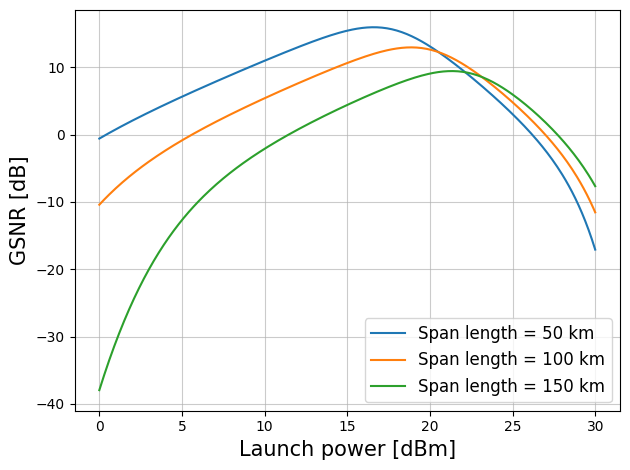

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from snr_calculator_Silas import SNR_GD

# 논문 Figure 1 조건
Ltot = 6000          # 전체 전송거리 [km]
alpha = 0.15         # 감쇠 [dB/km]
NF = 4.5             # EDFA Noise Figure [dB]
gamma = 0.81         # 비선형계수 [1/(W·km)]
D = 21e-12           # 분산 [s/(km·nm)]
Rs = 100e9           # Symbol rate [Baud]
delta_f = 112.5e9    # 채널 간격 [Hz]
B = 4.3e12           # 전체 대역폭 [Hz]
lamb = 1550          # 파장 [nm]
gamma_XT = 0         # Crosstalk 없음
l_FIFO = 0           # Figure 1에서는 FI/FO 손실 없음

# 전체 WDM Launch power: 0~30 dBm
launch_power_dbm = np.linspace(0, 30, 301)

# dBm → W 변환
Ps = 10 ** ((launch_power_dbm - 30) / 10)

plt.figure(figsize=(6.4, 4.8))

for span_length in [50, 100, 150]:

    # Span 개수
    N = int(Ltot / span_length)

    gsnr_linear = SNR_GD(
        Ps=Ps,
        lamb=lamb,
        alpha=alpha,
        NF=NF,
        N=N,
        gamma=gamma,
        Ltot=Ltot,
        B=B,
        D=D,
        Rs=Rs,
        gamma_XT=gamma_XT,
        l_FIFO=l_FIFO,
        delta_f=delta_f
    )

    gsnr_db = 10 * np.log10(gsnr_linear)

    plt.plot(
        launch_power_dbm,
        gsnr_db,
        label=f"Span length = {span_length} km"
    )

    peak = np.argmax(gsnr_db)
    print(
        f"{span_length} km: "
        f"최대 GSNR = {gsnr_db[peak]:.2f} dB, "
        f"Launch power = {launch_power_dbm[peak]:.1f} dBm"
    )

plt.xlabel("Launch power [dBm]", fontsize=15)
plt.ylabel("GSNR [dB]", fontsize=15)
plt.xlim(-1.5, 31.5)
plt.ylim(-41, 18.5)
plt.grid(True, alpha=0.65)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()

plt.savefig("Figure1_GSNR.png", dpi=300, bbox_inches="tight")
plt.show()